# E1 — MLP trên landmark đã chuẩn hóa (khung cố định index=22)

Thực nghiệm E1 dùng cùng khung thứ 23/45 và cùng kiến trúc MLP với E0. Khác biệt duy nhất là landmark được **đưa cổ tay về gốc tọa độ (wrist-centering)** và **chuẩn hóa kích thước bàn tay (scale-normalization)** trước khi đưa vào MLP.

Đánh giá theo leave-one-subject-out: train trên 3 người, test trên người còn lại và xoay đủ 4 lượt.

## 1. Cài đặt
Kaggle thường đã có sẵn NumPy, PyTorch và Matplotlib. Chỉ bỏ comment cell dưới nếu môi trường báo thiếu thư viện.

In [4]:
# !pip install torch matplotlib --quiet

## 2. Import và cấu hình

In [5]:
import re
import json
import time
from pathlib import Path
from typing import Protocol

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from IPython.display import display

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang chạy trên: {DEVICE}")

# Tự dò thư mục raw/{person}/*.npy để không phụ thuộc slug Kaggle dùng '-' hay '_'.
LANDMARK_CANDIDATES = [
    folder for folder in Path("/kaggle/input").rglob("raw")
    if folder.is_dir() and any(folder.glob("*/*.npy"))
]
if not LANDMARK_CANDIDATES:
    raise FileNotFoundError(
        "Không tìm thấy landmark .npy trong /kaggle/input. "
        "Hãy Add Data dataset vietnamese-sign-language-alphabet."
    )
LANDMARK_DIR = sorted(LANDMARK_CANDIDATES)[0]
print(f"Dùng LANDMARK_DIR: {LANDMARK_DIR}")

PEOPLE = ("hau", "khoi", "tai", "vy")
FNAME_RE = re.compile(r"^([a-z_]+)_([a-z]+)_([AB])_(\d+)\.npy$")

OUTPUT_DIR = Path("/kaggle/working/e1_outputs")
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
PLOT_DIR = OUTPUT_DIR / "plots"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
RESULT_PATH = OUTPUT_DIR / "E1_results.json"

FRAME_INDEX = 22
EPOCHS = 100
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
VAL_RATIO = 0.15
SEED = 42
EPSILON = 1e-6

BLUE = "#2a78d6"
ORANGE = "#eb6834"

Đang chạy trên: cuda
Dùng LANDMARK_DIR: /kaggle/input/datasets/hauuto/vietnamese-sign-language-alphabet/landmarks/landmarks/raw


## 3. Đọc dữ liệu landmark

In [6]:
def load_all_landmarks():
    """Đọc và kiểm tra toàn bộ file landmark; trả về danh sách record hợp lệ.

    Mỗi record chứa nhãn, người ký, block, số thứ tự và mảng landmark.
    Mảng hợp lệ có 45 bước và 63 (một tay) hoặc 126 (hai tay) đặc trưng.
    """
    records = []  # Danh sách kết quả sau khi lọc file lỗi.
    # Duyệt theo thứ tự cố định để lần chạy sau có thứ tự dữ liệu giống nhau.
    for file_path in sorted(LANDMARK_DIR.glob("*/*.npy")):
        # Tách code/person/block/sequence từ tên file theo quy ước của dataset.
        match = FNAME_RE.match(file_path.name)
        if not match:
            print(f"CẢNH BÁO: tên file không đúng quy ước: {file_path.name}")
            continue
        code, person, block, sequence = match.groups()
        array = np.load(file_path)  # Nạp chuỗi landmark đã resample về 45 bước.
        # Loại file sai cấu trúc trước khi np.stack để tránh lỗi giữa lúc train.
        if array.ndim != 2 or array.shape[0] != 45 or array.shape[1] % 63 != 0:
            print(f"CẢNH BÁO: bỏ qua {file_path.name}, shape không hợp lệ: {array.shape}")
            continue
        # Giữ metadata cùng dữ liệu để khung cross-subject có thể chia theo người.
        records.append({
            "code": code,
            "person": person,
            "block": block,
            "seq": int(sequence),
            "arr": array,
        })
    return records  # Không biến đổi landmark tại đây; E1 chuẩn hóa trong strategy.


records = load_all_landmarks()
if not records:
    raise RuntimeError(f"Không đọc được mẫu hợp lệ nào từ {LANDMARK_DIR}")

ALL_CLASSES = sorted({record["code"] for record in records})
CODE_TO_INDEX = {code: index for index, code in enumerate(ALL_CLASSES)}
INDEX_TO_CODE = {index: code for code, index in CODE_TO_INDEX.items()}

print(f"Tổng số mẫu: {len(records)}")
print(f"Số lớp: {len(ALL_CLASSES)}")
print("Số mẫu theo người:", {p: sum(r["person"] == p for r in records) for p in PEOPLE})

Tổng số mẫu: 640
Số lớp: 34
Số mẫu theo người: {'hau': 160, 'khoi': 160, 'tai': 160, 'vy': 160}


## 4. Khung đánh giá cross-subject
Khung này giữ nhiệm vụ chung: mỗi lượt chọn 1 người làm test, 3 người còn lại làm train, sau đó gọi các hàm của strategy.

In [7]:
class ModelStrategy(Protocol):
    """Giao diện mà mọi strategy E0/E1/E2/E3 phải cung cấp."""

    def prepare_input(self, X: np.ndarray) -> np.ndarray:
        """Biến đổi chuỗi landmark thô thành đầu vào phù hợp với mô hình."""
        ...

    def train(self, X_train, y_train, test_person: str):
        """Huấn luyện một fold và trả về trạng thái mô hình tốt nhất."""
        ...

    def predict(self, model_state, X_test) -> np.ndarray:
        """Dự đoán chỉ số lớp cho toàn bộ tập test của fold hiện tại."""
        ...

    def measure_latency(self, model_state, X_sample) -> float:
        """Đo thời gian suy luận một mẫu trên CPU, đơn vị mili-giây."""
        ...


def run_cross_subject(records, strategy: ModelStrategy, people=PEOPLE):
    """Chạy leave-one-subject-out: 3 người train, 1 người test, đủ 4 lượt.

    Hàm này chỉ điều phối dữ liệu và metric; chi tiết MLP/chuẩn hóa thuộc strategy.
    """
    results = []  # Lưu accuracy và latency của từng người test.
    for test_person in people:
        print(f"\n{'=' * 18} Fold test={test_person} {'=' * 18}")
        # Tuyệt đối không để mẫu của test_person xuất hiện trong tập train.
        train_records = [r for r in records if r["person"] != test_person]
        test_records = [r for r in records if r["person"] == test_person]

        # Ghép từng sample thành tensor (N, 45, D) và mã hóa nhãn thành số.
        X_train_raw = np.stack([r["arr"] for r in train_records])
        y_train = np.asarray([CODE_TO_INDEX[r["code"]] for r in train_records])
        X_test_raw = np.stack([r["arr"] for r in test_records])
        y_test = np.asarray([CODE_TO_INDEX[r["code"]] for r in test_records])

        # E1 chọn frame 22 rồi wrist-center và scale-normalize tại đây.
        X_train = strategy.prepare_input(X_train_raw)
        X_test = strategy.prepare_input(X_test_raw)

        # Train chỉ nhận dữ liệu ba người; tập người test chưa được dùng.
        model_state = strategy.train(X_train, y_train, test_person=test_person)
        y_pred = strategy.predict(model_state, X_test)
        accuracy = float(np.mean(y_pred == y_test))  # Top-1 accuracy của fold.
        latency_ms = strategy.measure_latency(model_state, X_test[:1])

        result = {
            "test_person": test_person,
            "train_samples": len(train_records),
            "test_samples": len(test_records),
            "accuracy": accuracy,
            "latency_ms": latency_ms,
        }
        results.append(result)
        print(f"Test trên {test_person}: accuracy={accuracy:.3f}, latency={latency_ms:.2f} ms")

    # Tổng hợp mean ± population standard deviation trên bốn người.
    accuracies = [r["accuracy"] for r in results]
    latencies = [r["latency_ms"] for r in results]
    print(
        f"\nTrung bình: accuracy={np.mean(accuracies):.3f} (±{np.std(accuracies):.3f}), "
        f"latency={np.mean(latencies):.2f} ms (±{np.std(latencies):.2f} ms)"
    )
    return results

## 5. Vẽ lịch sử huấn luyện
Mỗi fold tạo một biểu đồ gồm train loss và validation accuracy, vừa hiển thị trong notebook vừa lưu PNG.

In [8]:
def plot_history(history, test_person: str, fold_index: int):
    """Vẽ, hiển thị và lưu train loss/validation accuracy của một fold."""
    # Loss và accuracy khác thang đo, vì vậy dùng hai trục y chung một trục epoch.
    figure, loss_axis = plt.subplots(figsize=(7, 4.5))
    loss_axis.plot(history["epoch"], history["train_loss"], color=BLUE, linewidth=2, label="Train loss")
    loss_axis.set_xlabel("Epoch")
    loss_axis.set_ylabel("Train loss", color=BLUE)
    loss_axis.tick_params(axis="y", labelcolor=BLUE)

    accuracy_axis = loss_axis.twinx()  # Trục y bên phải dành cho accuracy [0, 1].
    accuracy_axis.plot(history["epoch"], history["val_accuracy"], color=ORANGE, linewidth=2, label="Val accuracy")
    accuracy_axis.set_ylabel("Val accuracy", color=ORANGE)
    accuracy_axis.tick_params(axis="y", labelcolor=ORANGE)
    accuracy_axis.set_ylim(0.0, 1.0)

    loss_lines, loss_labels = loss_axis.get_legend_handles_labels()
    accuracy_lines, accuracy_labels = accuracy_axis.get_legend_handles_labels()
    loss_axis.legend(loss_lines + accuracy_lines, loss_labels + accuracy_labels, loc="center right")
    figure.suptitle(f"E1 — Train loss & Val accuracy (fold test={test_person})")
    figure.tight_layout()

    # Lưu ảnh để tải về làm báo cáo, đồng thời display ngay trong Kaggle Notebook.
    output_path = PLOT_DIR / f"E1_fold{fold_index}_{test_person}.png"
    figure.savefig(output_path, dpi=150, bbox_inches="tight")
    display(figure)
    plt.close(figure)  # Giải phóng figure, tránh tích lũy bộ nhớ qua bốn fold.
    print(f"Đã lưu biểu đồ: {output_path}")

## 6. Kiến trúc MLP
Giữ đúng kiến trúc E0 (`input → 128 → 64 → 34`) để khác biệt kết quả chỉ đến từ bước chuẩn hóa E1.

In [9]:
class MLPClassifier(nn.Module):
    """MLP phân loại một vector landmark; kiến trúc được giữ giống E0."""

    def __init__(self, input_dim: int, num_classes: int):
        """Tạo mạng input → 128 → 64 → num_classes với ReLU và dropout."""
        super().__init__()
        # ReLU tạo phi tuyến; dropout 0.3 giảm overfitting trên dataset nhỏ.
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        """Lan truyền batch x qua MLP và trả về logits chưa qua softmax."""
        # CrossEntropyLoss nhận logits trực tiếp nên không đặt Softmax trong model.
        return self.network(x)

## 7. Strategy E1

`prepare_input()` thực hiện đúng nhiệm vụ E1:

1. Lấy cố định frame `index=22`.
2. Trừ landmark cổ tay (landmark 0) khỏi 21 điểm.
3. Chia cho khoảng cách lớn nhất từ cổ tay tới một landmark.
4. Flatten lại để đưa vào MLP.

Mẫu mất tay (toàn số 0) vẫn an toàn nhờ `EPSILON`.

In [ ]:
class E1Strategy:
    """Đóng gói tiền xử lý, train, predict và đo latency cho thực nghiệm E1."""

    def __init__(self):
        """Khởi tạo bộ đếm fold để đặt seed và tên file không trùng nhau."""
        self.fold_index = 0

    def prepare_input(self, X: np.ndarray) -> np.ndarray:
        """Lấy frame 22, đưa cổ tay về gốc và chuẩn hóa tỷ lệ từng bàn tay.

        Input: (N, 45, 63) hoặc (N, 45, 126). Output: (N, 63/126).
        """
        # Kiểm tra sớm để lỗi dữ liệu có thông báo rõ thay vì lỗi reshape khó hiểu.
        if X.ndim != 3 or X.shape[1] <= FRAME_INDEX or X.shape[2] % 63 != 0:
            raise ValueError(f"E1 nhận shape (N, 45, 63/126), nhưng nhận được {X.shape}")

        # E0/E1 đều dùng cố định khung thứ 23 (Python index 22).
        selected = X[:, FRAME_INDEX, :].astype(np.float32, copy=True)
        # Khôi phục cấu trúc 21 điểm × (x,y,z); -1 tự suy ra một hay hai tay.
        hands = selected.reshape(selected.shape[0], -1, 21, 3)
        # Landmark 0 là cổ tay: phép trừ tạo hệ tọa độ tương đối, bất biến tịnh tiến.
        centered = hands - hands[:, :, 0:1, :]
        # Khoảng cách Euclid 3D từ cổ tay tới từng điểm, shape (N, hands, 21).
        distances = np.linalg.norm(centered, axis=-1)
        # Bán kính lớn nhất đại diện scale riêng của từng tay trong từng sample.
        scales = np.max(distances, axis=-1, keepdims=True)[..., np.newaxis]
        # EPSILON giữ mẫu mất tay (scale=0) là vector 0 và ngăn NaN/Inf.
        normalized = centered / np.maximum(scales, EPSILON)
        # Flatten lại thành vector để đưa vào Linear layer của MLP.
        return normalized.reshape(selected.shape[0], -1).astype(np.float32)

    @staticmethod
    def split_train_validation(y: np.ndarray, seed: int):
        """Chia train/validation có phân tầng theo lớp, chỉ từ ba người train."""
        rng = np.random.default_rng(seed)  # RNG cục bộ để chia dữ liệu tái lập được.
        train_indices, validation_indices = [], []
        # Xử lý từng lớp riêng để cả train và validation đều có mọi lớp.
        for class_index in np.unique(y):
            indices = np.flatnonzero(y == class_index)
            rng.shuffle(indices)
            if len(indices) < 2:
                raise ValueError(f"Lớp {class_index} có ít hơn 2 mẫu trong tập train")
            # Ít nhất 1 validation nhưng luôn chừa ít nhất 1 mẫu để train.
            validation_count = min(max(1, int(len(indices) * VAL_RATIO)), len(indices) - 1)
            validation_indices.extend(indices[:validation_count])
            train_indices.extend(indices[validation_count:])
        return np.asarray(train_indices), np.asarray(validation_indices)

    def train(self, X_train, y_train, test_person: str):
        """Train MLP, chọn epoch tốt nhất theo validation và lưu artefact của fold."""
        # Seed khác nhau nhưng cố định theo fold giúp kết quả có thể tái lập.
        fold_seed = SEED + self.fold_index
        np.random.seed(fold_seed)
        torch.manual_seed(fold_seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(fold_seed)

        # Validation được tách từ ba người train, hoàn toàn không dùng test_person.
        train_indices, validation_indices = self.split_train_validation(y_train, fold_seed)
        X_fit, y_fit = X_train[train_indices], y_train[train_indices]
        X_validation, y_validation = X_train[validation_indices], y_train[validation_indices]

        # Giữ kiến trúc và siêu tham số giống E0 để so sánh ablation công bằng.
        model = MLPClassifier(X_fit.shape[1], len(ALL_CLASSES)).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
        # Giảm learning rate khi val accuracy chững 15 epoch.
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", factor=0.5, patience=15, min_lr=1e-5
        )
        criterion = nn.CrossEntropyLoss()

        # Generator cố định khiến thứ tự shuffle của DataLoader tái lập được.
        generator = torch.Generator().manual_seed(fold_seed)
        loader = DataLoader(
            TensorDataset(torch.from_numpy(X_fit).float(), torch.from_numpy(y_fit).long()),
            batch_size=BATCH_SIZE, shuffle=True, generator=generator,
        )
        X_validation_tensor = torch.from_numpy(X_validation).float().to(DEVICE)
        y_validation_tensor = torch.from_numpy(y_validation).long().to(DEVICE)

        # History phục vụ biểu đồ; best_state phục vụ model selection.
        history = {"epoch": [], "train_loss": [], "val_accuracy": []}
        best_accuracy, best_epoch, best_state = -1.0, 0, None

        for epoch in range(EPOCHS):
            model.train()  # Bật dropout và chế độ huấn luyện.
            total_loss = 0.0
            for features, targets in loader:
                features, targets = features.to(DEVICE), targets.to(DEVICE)
                optimizer.zero_grad(set_to_none=True)  # Không cộng dồn gradient từ batch trước.
                loss = criterion(model(features), targets)
                loss.backward()  # Lan truyền ngược để tính gradient.
                optimizer.step()  # Adam cập nhật trọng số.
                total_loss += loss.item() * features.size(0)

            train_loss = total_loss / len(X_fit)
            model.eval()  # Tắt dropout để validation ổn định.
            # Tắt tính toán gradient để tiết kiệm bộ nhớ.
            with torch.inference_mode():
                validation_predictions = model(X_validation_tensor).argmax(dim=1)
                validation_accuracy = float(
                    (validation_predictions == y_validation_tensor).float().mean().item()
                )
            scheduler.step(validation_accuracy)  # Scheduler theo metric cần tối đa hóa.

            history["epoch"].append(epoch + 1)
            history["train_loss"].append(train_loss)
            history["val_accuracy"].append(validation_accuracy)

            # Sao chép checkpoint lên CPU khi validation tốt hơn; không nhìn test accuracy.
            if validation_accuracy > best_accuracy:
                best_accuracy = validation_accuracy
                best_epoch = epoch + 1
                best_state = {
                    name: value.detach().cpu().clone()
                    for name, value in model.state_dict().items()
                }

            if (epoch + 1) % 20 == 0:
                current_lr = optimizer.param_groups[0]["lr"]
                print(
                    f"  [E1 fold {self.fold_index + 1}/4] epoch {epoch + 1}/{EPOCHS} "
                    f"loss={train_loss:.4f} val_acc={validation_accuracy:.3f} lr={current_lr:.2e}"
                )

        # Khôi phục epoch tốt nhất thay vì mặc định dùng epoch cuối.
        model.load_state_dict(best_state)
        model.eval()
        checkpoint_path = CHECKPOINT_DIR / f"E1_fold{self.fold_index}_{test_person}.pt"
        torch.save({
            "experiment": "E1",
            "test_person": test_person,
            "frame_index": FRAME_INDEX,
            "input_dim": int(X_fit.shape[1]),
            "classes": ALL_CLASSES,
            "best_epoch": best_epoch,
            "best_val_accuracy": best_accuracy,
            "model_state_dict": model.state_dict(),
        }, checkpoint_path)

        print(f"Chọn epoch {best_epoch}/{EPOCHS}, val_acc={best_accuracy:.3f}")
        print(f"Đã lưu checkpoint: {checkpoint_path}")
        plot_history(history, test_person, self.fold_index)
        self.fold_index += 1
        return model

    def predict(self, model_state, X_test) -> np.ndarray:
        """Suy luận toàn bộ X_test và trả về chỉ số lớp có logit lớn nhất."""
        model_state.eval()
        # Tắt tính toán gradient và tính toán loss để tiết kiệm bộ nhớ.
        with torch.inference_mode():
            features = torch.from_numpy(X_test).float().to(DEVICE)
            return model_state(features).argmax(dim=1).cpu().numpy()

    def measure_latency(self, model_state, X_sample) -> float:
        """Đo latency trung bình của một mẫu qua 100 lượt suy luận CPU."""
        # CPU phản ánh mục tiêu demo phổ thông; nhớ thiết bị cũ để phục hồi sau phép đo.
        original_device = next(model_state.parameters()).device
        model_state.to("cpu").eval()
        sample = torch.from_numpy(X_sample).float()
        with torch.inference_mode():
            # Warm-up 10 lượt để loại chi phí khởi tạo khỏi thống kê.
            for _ in range(10):
                model_state(sample)
            elapsed_ms = []
            # perf_counter có độ phân giải cao, phù hợp đo khoảng thời gian rất ngắn.
            for _ in range(100):
                start = time.perf_counter()
                model_state(sample)
                elapsed_ms.append((time.perf_counter() - start) * 1000.0)
        model_state.to(original_device)
        return float(np.mean(elapsed_ms))

## 8. Kiểm tra nhanh bước chuẩn hóa
Sau wrist-centering, tọa độ cổ tay phải bằng 0. Mẫu mất tay không được sinh NaN/Inf.

In [11]:
strategy = E1Strategy()
sample_raw = np.stack([record["arr"] for record in records[:8]])
sample_normalized = strategy.prepare_input(sample_raw)
sample_hands = sample_normalized.reshape(sample_normalized.shape[0], -1, 21, 3)
assert np.allclose(sample_hands[:, :, 0, :], 0.0), "Cổ tay chưa được đưa về gốc"
assert np.isfinite(sample_normalized).all(), "Chuẩn hóa sinh NaN hoặc Inf"
print(f"Shape trước chuẩn hóa: {sample_raw.shape}")
print(f"Shape sau lấy frame + chuẩn hóa: {sample_normalized.shape}")
print("Kiểm tra chuẩn hóa: OK")

Shape trước chuẩn hóa: (8, 45, 63)
Shape sau lấy frame + chuẩn hóa: (8, 63)
Kiểm tra chuẩn hóa: OK


## 9. Chạy đánh giá E1 và lưu kết quả
Cell này train đủ 4 fold. Sau mỗi fold, notebook hiển thị biểu đồ và lưu checkpoint tốt nhất.


================== Fold test=hau ==================
  [E1 fold 1/4] epoch 20/100 loss=1.9472 val_acc=0.435 lr=1.00e-03
  [E1 fold 1/4] epoch 40/100 loss=1.4490 val_acc=0.609 lr=1.00e-03
  [E1 fold 1/4] epoch 60/100 loss=1.2054 val_acc=0.652 lr=1.00e-03
  [E1 fold 1/4] epoch 80/100 loss=1.0924 val_acc=0.652 lr=5.00e-04
  [E1 fold 1/4] epoch 100/100 loss=1.0206 val_acc=0.630 lr=1.25e-04
Chọn epoch 65/100, val_acc=0.674
Đã lưu checkpoint: /kaggle/working/e1_outputs/checkpoints/E1_fold0_hau.pt


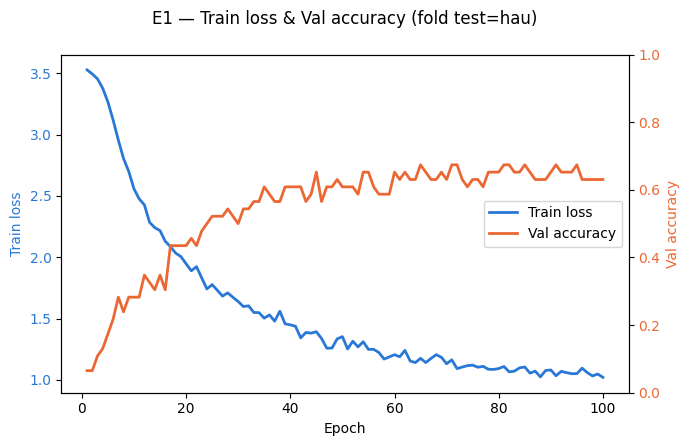

Đã lưu biểu đồ: /kaggle/working/e1_outputs/plots/E1_fold0_hau.png
Test trên hau: accuracy=0.438, latency=0.08 ms

================== Fold test=khoi ==================
  [E1 fold 2/4] epoch 20/100 loss=2.0637 val_acc=0.435 lr=1.00e-03
  [E1 fold 2/4] epoch 40/100 loss=1.5375 val_acc=0.435 lr=1.00e-03
  [E1 fold 2/4] epoch 60/100 loss=1.3713 val_acc=0.500 lr=5.00e-04
  [E1 fold 2/4] epoch 80/100 loss=1.2482 val_acc=0.500 lr=2.50e-04
  [E1 fold 2/4] epoch 100/100 loss=1.2262 val_acc=0.522 lr=1.25e-04
Chọn epoch 78/100, val_acc=0.565
Đã lưu checkpoint: /kaggle/working/e1_outputs/checkpoints/E1_fold1_khoi.pt


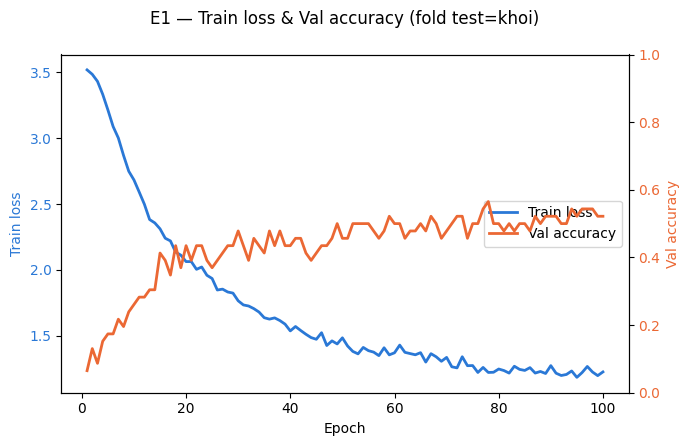

Đã lưu biểu đồ: /kaggle/working/e1_outputs/plots/E1_fold1_khoi.png
Test trên khoi: accuracy=0.562, latency=0.09 ms

================== Fold test=tai ==================
  [E1 fold 3/4] epoch 20/100 loss=2.0508 val_acc=0.500 lr=1.00e-03
  [E1 fold 3/4] epoch 40/100 loss=1.5723 val_acc=0.522 lr=1.00e-03
  [E1 fold 3/4] epoch 60/100 loss=1.3001 val_acc=0.609 lr=5.00e-04
  [E1 fold 3/4] epoch 80/100 loss=1.2640 val_acc=0.630 lr=2.50e-04
  [E1 fold 3/4] epoch 100/100 loss=1.1710 val_acc=0.630 lr=1.25e-04
Chọn epoch 64/100, val_acc=0.652
Đã lưu checkpoint: /kaggle/working/e1_outputs/checkpoints/E1_fold2_tai.pt


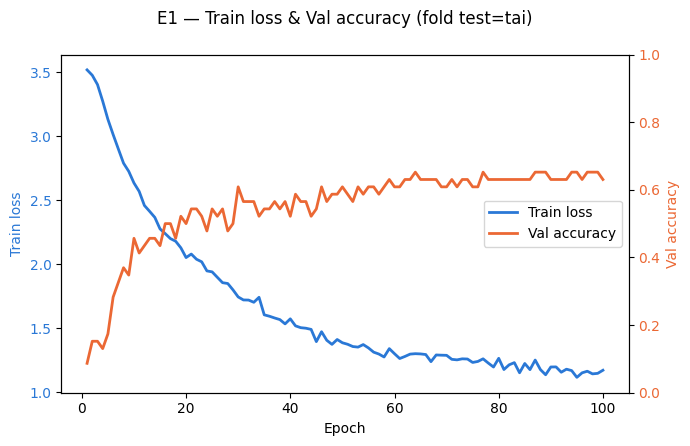

Đã lưu biểu đồ: /kaggle/working/e1_outputs/plots/E1_fold2_tai.png
Test trên tai: accuracy=0.406, latency=0.08 ms

================== Fold test=vy ==================
  [E1 fold 4/4] epoch 20/100 loss=2.1137 val_acc=0.391 lr=1.00e-03
  [E1 fold 4/4] epoch 40/100 loss=1.6348 val_acc=0.478 lr=1.00e-03
  [E1 fold 4/4] epoch 60/100 loss=1.3417 val_acc=0.565 lr=1.00e-03
  [E1 fold 4/4] epoch 80/100 loss=1.1552 val_acc=0.587 lr=1.00e-03
  [E1 fold 4/4] epoch 100/100 loss=1.0236 val_acc=0.587 lr=1.00e-03
Chọn epoch 91/100, val_acc=0.674
Đã lưu checkpoint: /kaggle/working/e1_outputs/checkpoints/E1_fold3_vy.pt


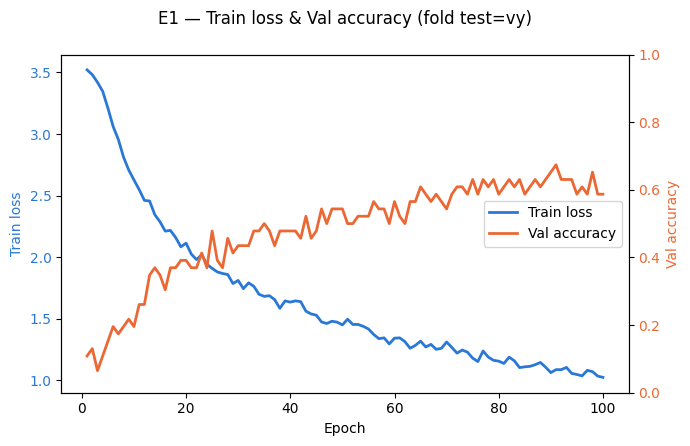

Đã lưu biểu đồ: /kaggle/working/e1_outputs/plots/E1_fold3_vy.png
Test trên vy: accuracy=0.594, latency=0.08 ms

Trung bình: accuracy=0.500 (±0.080), latency=0.08 ms (±0.00 ms)

Đã lưu kết quả: /kaggle/working/e1_outputs/E1_results.json
Checkpoint: /kaggle/working/e1_outputs/checkpoints
Biểu đồ: /kaggle/working/e1_outputs/plots
Các file cần tải về: E1_results.json, checkpoints/*.pt, plots/*.png và notebook đã chạy.


In [12]:
strategy = E1Strategy()
results = run_cross_subject(records, strategy)

accuracies = [result["accuracy"] for result in results]
latencies = [result["latency_ms"] for result in results]
summary = {
    "experiment": "E1",
    "description": "MLP frame index=22, wrist-centering và scale-normalization",
    "configuration": {
        "frame_index": FRAME_INDEX,
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "validation_ratio": VAL_RATIO,
        "seed": SEED,
        "classes": len(ALL_CLASSES),
    },
    "results": results,
    "accuracy_mean": float(np.mean(accuracies)),
    "accuracy_std": float(np.std(accuracies)),
    "latency_mean_ms": float(np.mean(latencies)),
    "latency_std_ms": float(np.std(latencies)),
}
RESULT_PATH.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

print(f"\nĐã lưu kết quả: {RESULT_PATH}")
print(f"Checkpoint: {CHECKPOINT_DIR}")
print(f"Biểu đồ: {PLOT_DIR}")
print("Các file cần tải về: E1_results.json, checkpoints/*.pt, plots/*.png và notebook đã chạy.")